# EN3160 Assignment 1 - Intensity Transformations and Neighborhood Filtering

**Name:** Gimhan <br>
**Index No:** 230018T <br>
**GitHub:** https://github.com/Gimadikaram/EN3160-Image-Processing-Assignment-1




In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 4)
IMG_DIR = "C:/Users/ASUS/Downloads/EN3160-Image-Processing-Assignment-1/inputs images/"


## Question 1 - Piecewise-linear intensity transformation



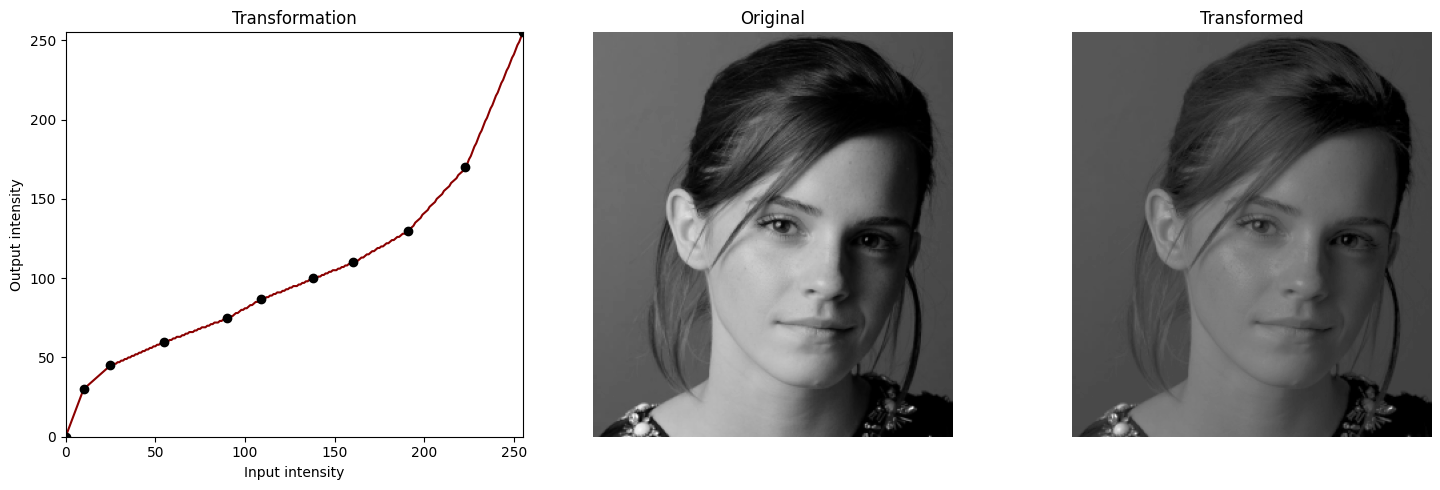

In [6]:
def intensity_transform(im, breakpoints):
   
    bp = np.array(breakpoints, dtype=np.float64)
    xs, ys = bp[:, 0], bp[:, 1]
    x_full = np.arange(256)
    lut = np.clip(np.interp(x_full, xs, ys), 0, 255).astype(np.uint8)
    out = cv2.LUT(im, lut)
    return out, lut



img1 = cv2.imread(IMG_DIR + "q1.png", cv2.IMREAD_GRAYSCALE)

breakpoints = [
    [0, 0],
    [10,30],
    [25, 45],
    [55, 60],
    [90, 75],
    [109, 87],
    [138, 100],
    [160, 110],
    [191, 130],
    [223, 170],
    [255, 255]
]

transformed1, lut1 = intensity_transform(img1, breakpoints)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(np.arange(256), lut1, color='darkred')
axes[0].scatter(*zip(*breakpoints), color='black', zorder=3)
axes[0].set_xlim(0, 255); axes[0].set_ylim(0, 255)
axes[0].set_xlabel("Input intensity"); axes[0].set_ylabel("Output intensity")
axes[0].set_title("Transformation")

axes[1].imshow(img1, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Original"); axes[1].axis('off')

axes[2].imshow(transformed1, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Transformed"); axes[2].axis('off')

plt.tight_layout()
plt.show()




<h3>Discussion-</h3>
<b>Shadow Recovery:</b> A steep slope in the lower intensity range (e.g., mapping 25 to 45) lifts dark tones to reveal detail in the shadowed right side of the face.

<b>Highlight Compression:</b> A reduced slope across mid-to-high intensities (e.g., mapping 191 to 130) tones down overexposure on the left cheek and restores local contrast.

<b>Gradient Preservation:</b> Dense, closely spaced breakpoints ensure smooth piecewise linear interpolation, preserving natural luminance transitions in the hair and forehead without posterization while retaining the 255 white point.

## Question 2 - Accentuating white matter / gray matter


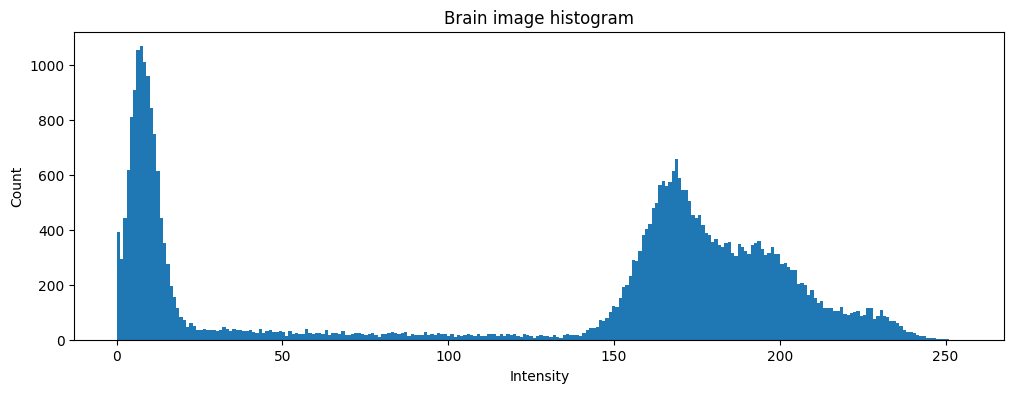

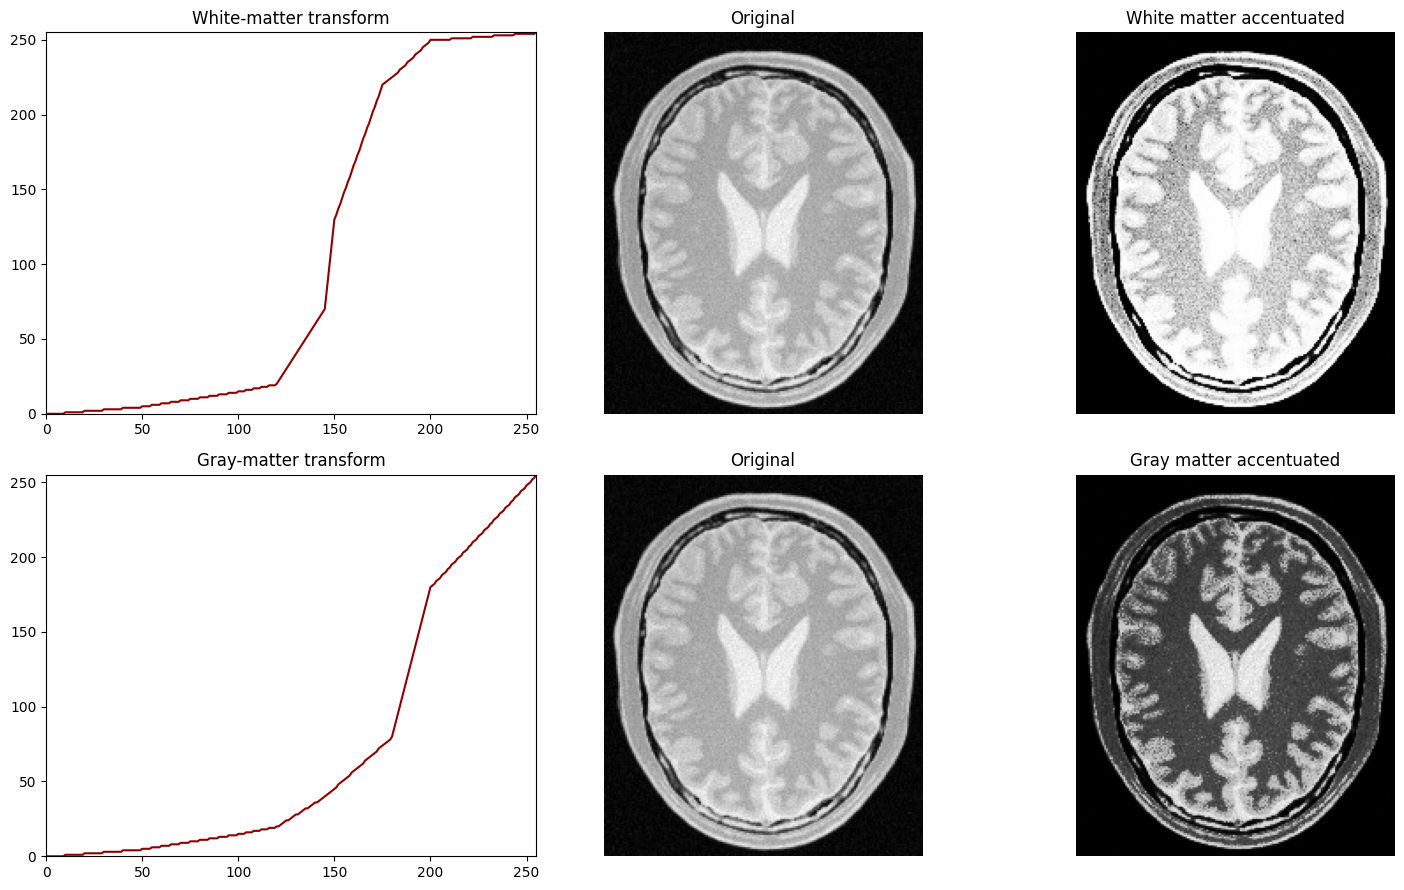

In [81]:
brain = cv2.imread(IMG_DIR + "q2.jpeg", cv2.IMREAD_GRAYSCALE)
plt.hist(brain.ravel(), bins=256, range=(0, 255))
plt.title("Brain image histogram")
plt.xlabel("Intensity"); plt.ylabel("Count")
plt.show()


white_matter_bp = [[0, 0],[50,5] ,[100, 15],[120,20], [145, 70],[150,130],[175,220], [180, 225], [200, 250], [255, 255]]
gray_matter_bp  = [[0, 0],[50,5] ,[100, 15],[120,20], [145, 40],[180,80], [200, 180], [255, 255]]

white_out, white_lut = intensity_transform(brain, white_matter_bp)
gray_out,  gray_lut  = intensity_transform(brain, gray_matter_bp)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].plot(white_lut, color='darkred'); axes[0, 0].set_title("White-matter transform")
axes[0, 0].set_xlim(0, 255); axes[0, 0].set_ylim(0, 255)
axes[0, 1].imshow(brain, cmap='gray'); axes[0, 1].set_title("Original"); axes[0, 1].axis('off')
axes[0, 2].imshow(white_out, cmap='gray'); axes[0, 2].set_title("White matter accentuated"); axes[0, 2].axis('off')

axes[1, 0].plot(gray_lut, color='darkred'); axes[1, 0].set_title("Gray-matter transform")
axes[1, 0].set_xlim(0, 255); axes[1, 0].set_ylim(0, 255)
axes[1, 1].imshow(brain, cmap='gray'); axes[1, 1].set_title("Original"); axes[1, 1].axis('off')
axes[1, 2].imshow(gray_out, cmap='gray'); axes[1, 2].set_title("Gray matter accentuated"); axes[1, 2].axis('off')

plt.tight_layout()
plt.show()



<b>White-Matter Transform:</b> Stretches the ~185-210 intensity band toward 255 to illuminate deep tracts and peri-ventricular regions, turning the ventricular horns into the brightest structures while suppressing darker tissues.

<b>Gray-Matter Transform:</b> Targets and stretches the ~145-180 intensity band to highlight the folded cortical ribbon along the outer brain boundary while dimming brighter white matter and CSF.

<b>Smooth Ramps:</b> Uses gradual transitions on either side of target bands to avoid harsh posterization and maintain natural tissue boundaries without binarizing the image.

## Question 3 - Gamma correction on the L plane (L\*a\*b\*)


In [83]:
def gamma_correct_L(img_bgr, gamma):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float64)
    L, a, b = cv2.split(lab)
    L_norm = L / 255.0
    L_gamma = np.clip(np.power(L_norm, gamma) * 255.0, 0, 255)
    lab_out = cv2.merge([L_gamma, a, b]).astype(np.uint8)
    return cv2.cvtColor(lab_out, cv2.COLOR_LAB2BGR)


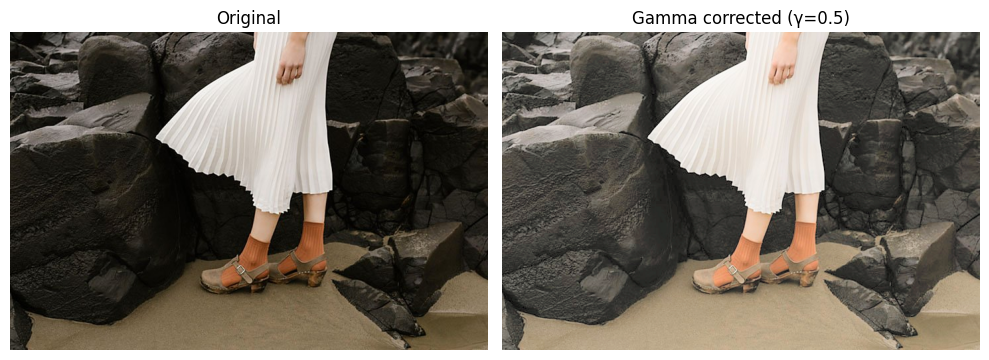

In [84]:
img3 = cv2.imread(IMG_DIR + "q3.jpeg")

gamma = 0.5
img3_gc = gamma_correct_L(img3, gamma)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)); axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img3_gc, cv2.COLOR_BGR2RGB)); axes[1].set_title(f"Gamma corrected (γ={gamma})"); axes[1].axis('off')
plt.tight_layout(); plt.show()


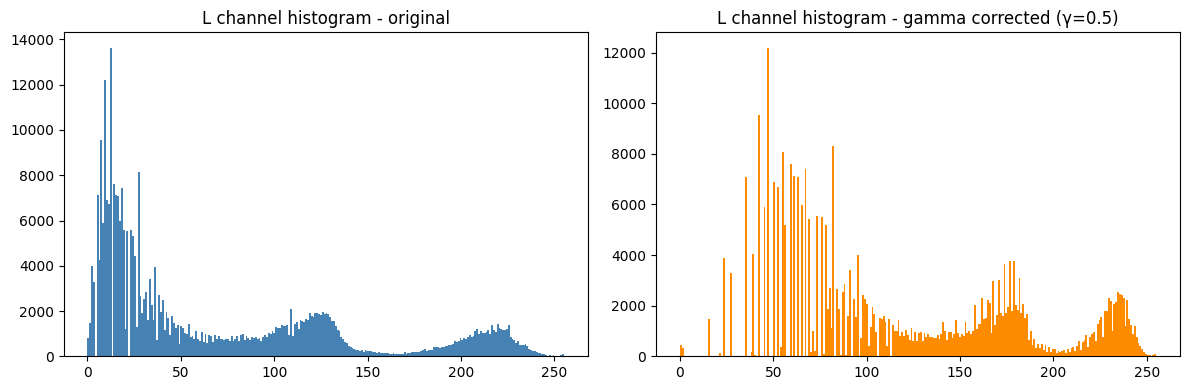

In [85]:
L_before = cv2.cvtColor(img3, cv2.COLOR_BGR2LAB)[:, :, 0]
L_after  = cv2.cvtColor(img3_gc, cv2.COLOR_BGR2LAB)[:, :, 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(L_before.ravel(), bins=256, range=(0, 255), color='steelblue')
axes[0].set_title("L channel histogram - original")
axes[1].hist(L_after.ravel(), bins=256, range=(0, 255), color='darkorange')
axes[1].set_title(f"L channel histogram - gamma corrected (γ={gamma})")
plt.tight_layout(); plt.show()


**γ = 0.5.** The original L-channel is heavily skewed dark (median L ≈ 38, only the white dress
sits up near 220) because the black volcanic rocks dominate the frame. γ=0.4 was tried first but
looked slightly flat/washed out; γ=0.6 under-recovered the shadow detail; γ=0.5 gave the best balance -
it lifts the rock texture out of near-black without pushing the already-bright dress toward clipping,
which is visible in the histogram as the left-hand mass shifting right while the right-hand (dress)
mass barely moves.


## Question 4 - Vibrance enhancement on the Saturation plane

$$f(x) = \min\Big(x + a \times 128\,e^{-\frac{(x-128)^2}{2\sigma^2}},\ 255\Big),\quad \sigma=70$$


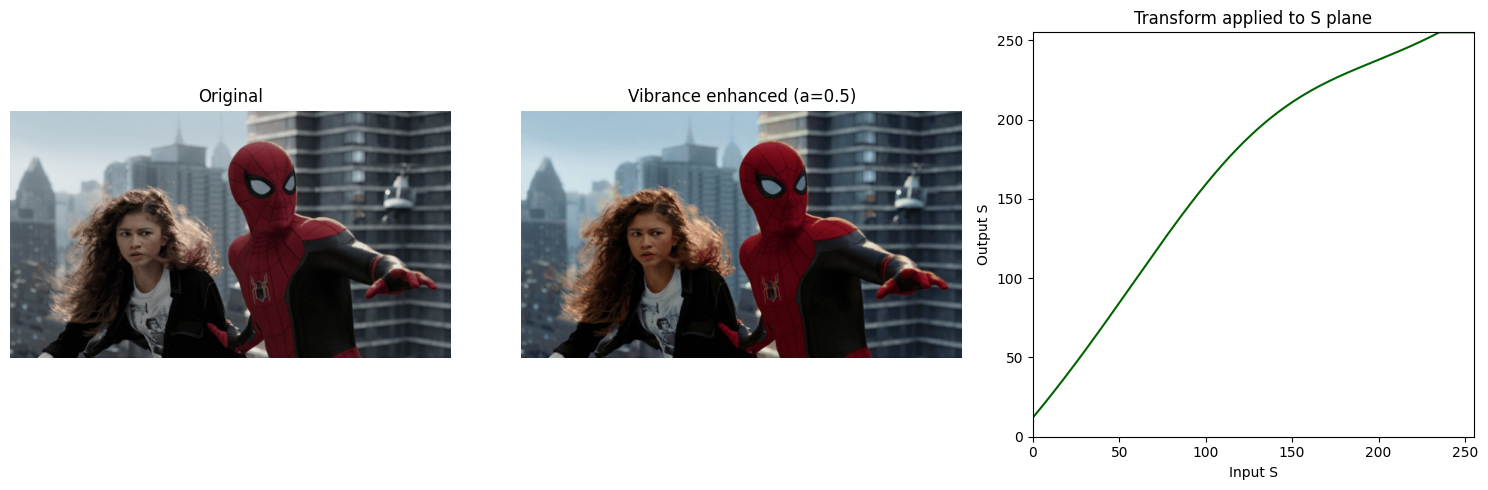

In [88]:
def vibrance_lut(a, sigma=70):
    x = np.arange(256, dtype=np.float64)
    y = np.minimum(x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2)), 255)
    return np.clip(y, 0, 255).astype(np.uint8), x, y


img4 = cv2.imread(IMG_DIR + "q4.jpeg")
hsv4 = cv2.cvtColor(img4, cv2.COLOR_BGR2HSV)
h4, s4, v4 = cv2.split(hsv4)

a = 0.5
lut4, x_plot, y_plot = vibrance_lut(a)
s4_new = cv2.LUT(s4, lut4)

hsv4_new = cv2.merge([h4, s4_new, v4])
img4_vib = cv2.cvtColor(hsv4_new, cv2.COLOR_HSV2BGR)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)); axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img4_vib, cv2.COLOR_BGR2RGB)); axes[1].set_title(f"Vibrance enhanced (a={a})"); axes[1].axis('off')
axes[2].plot(x_plot, y_plot, color='darkgreen'); axes[2].set_xlim(0, 255); axes[2].set_ylim(0, 255)
axes[2].set_xlabel("Input S"); axes[2].set_ylabel("Output S"); axes[2].set_title("Transform applied to S plane")
plt.tight_layout(); plt.show()


**a = 0.5.** The scene's saturation is fairly low overall (median S ≈ 44, most pixels well under
128), which is exactly the regime this Gaussian-shaped boost affects most. a=1.0 was tried and pushed
the red suit into an oversaturated, slightly unnatural orange and made the hair look artificially warm;
a=0.5 gives a clearly richer red suit and warmer skin/hair tones while the sky and building
greys - already low-S - stay essentially untouched, which is the "vibrance vs blanket saturation"
behaviour the formula is designed to produce.


## Question 5 - Histogram equalization from scratch


In [96]:
def histogram_equalize(im):
    """im: single-channel uint8 image. Returns (equalized_image, hist, cdf_lut)."""
    hist, _ = np.histogram(im.ravel(), bins=256, range=(0, 256))
    cdf = hist.cumsum()
    cdf_lut = np.round((cdf - cdf.min()) * 255.0 / (cdf.max() - cdf.min())).astype(np.uint8)
    equalized = cdf_lut[im]
    return equalized, hist, cdf_lut

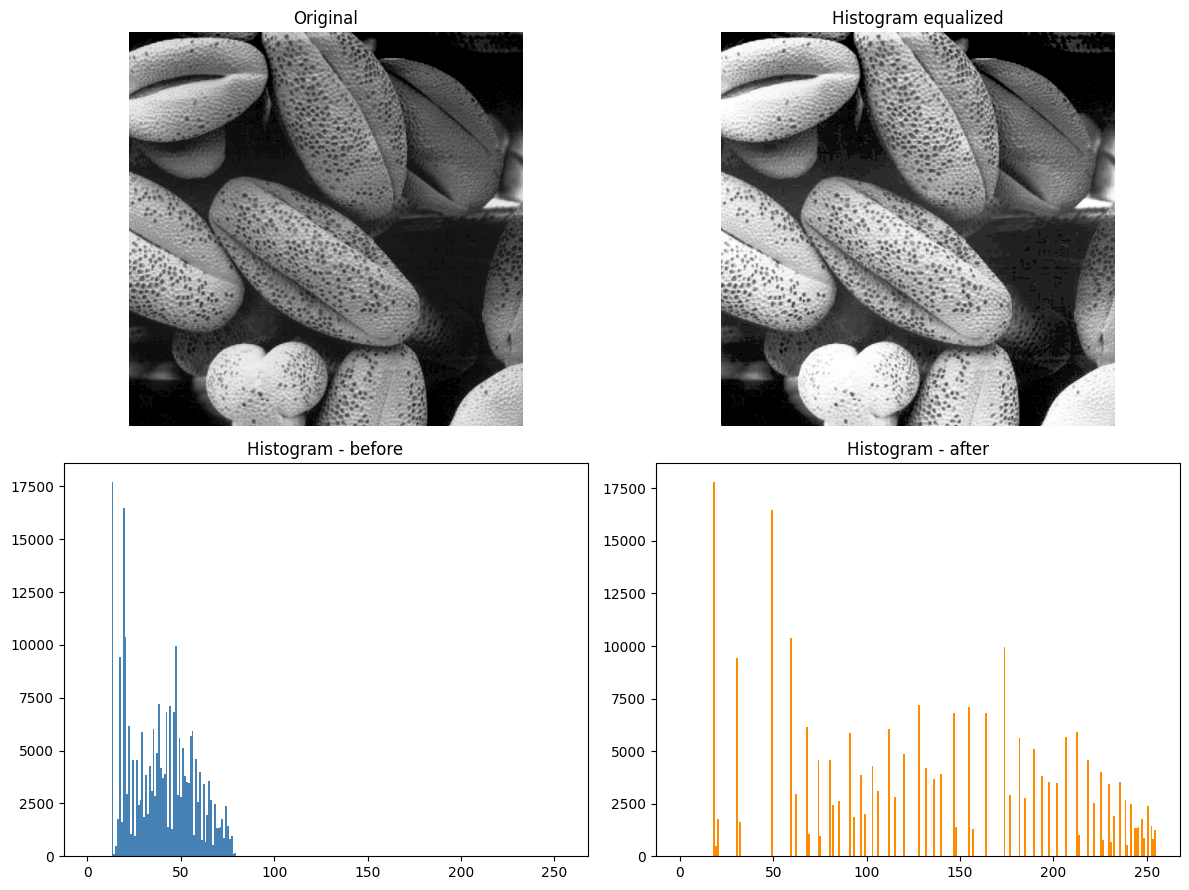

In [98]:
img5 = cv2.imread(IMG_DIR + "q5.tif", cv2.IMREAD_GRAYSCALE)
img5_eq, hist5, lut5 = histogram_equalize(img5)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0, 0].imshow(img5, cmap='gray'); axes[0, 0].set_title("Original"); axes[0, 0].axis('off')
axes[0, 1].imshow(img5_eq, cmap='gray'); axes[0, 1].set_title("Histogram equalized"); axes[0, 1].axis('off')
axes[1, 0].hist(img5.ravel(), bins=256, range=(0, 255), color='steelblue'); axes[1, 0].set_title("Histogram - before")
axes[1, 1].hist(img5_eq.ravel(), bins=256, range=(0, 255), color='darkorange'); axes[1, 1].set_title("Histogram - after")
plt.tight_layout(); plt.show()

**Discussion.** The original image only uses intensities 13-83 out of the full 0-255 range - it
looks almost uniformly dark gray, and the leaf speckle texture is barely visible. Equalizing stretches
that narrow 70-level band across the full range, and the speckled texture, leaf edges, and stem
separation all become clearly visible. This is about as strong a before/after case for histogram
equalization as you'll see - the original really is that low-contrast.


## Question 6 - Histogram equalization of the foreground only


The background here is a plain, low-saturation gray gradient, while the hair is a strongly
chromatic blonde - so the **Saturation** plane is the one that separates subject from background
cleanly (the Value plane doesn't, since the gray background's brightness overlaps the subject's).


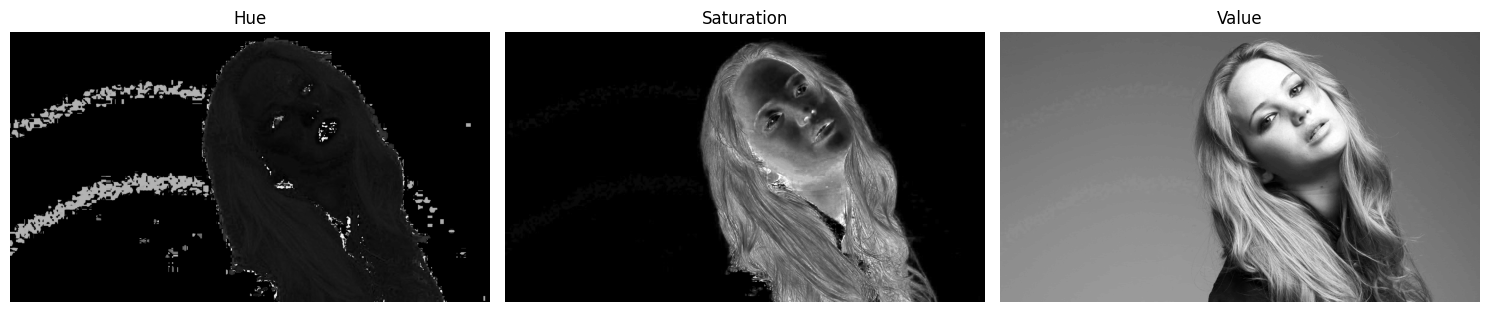

In [109]:
# --- Load image and split into HSV planes ---
img6 = cv2.imread(IMG_DIR + "q6.jpeg")
hsv6 = cv2.cvtColor(img6, cv2.COLOR_BGR2HSV)
h6, s6, v6 = cv2.split(hsv6)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(h6, cmap='gray'); axes[0].set_title("Hue"); axes[0].axis('off')
axes[1].imshow(s6, cmap='gray'); axes[1].set_title("Saturation"); axes[1].axis('off')
axes[2].imshow(v6, cmap='gray'); axes[2].set_title("Value"); axes[2].axis('off')
plt.tight_layout(); plt.show()







Otsu threshold on S plane: 60.0


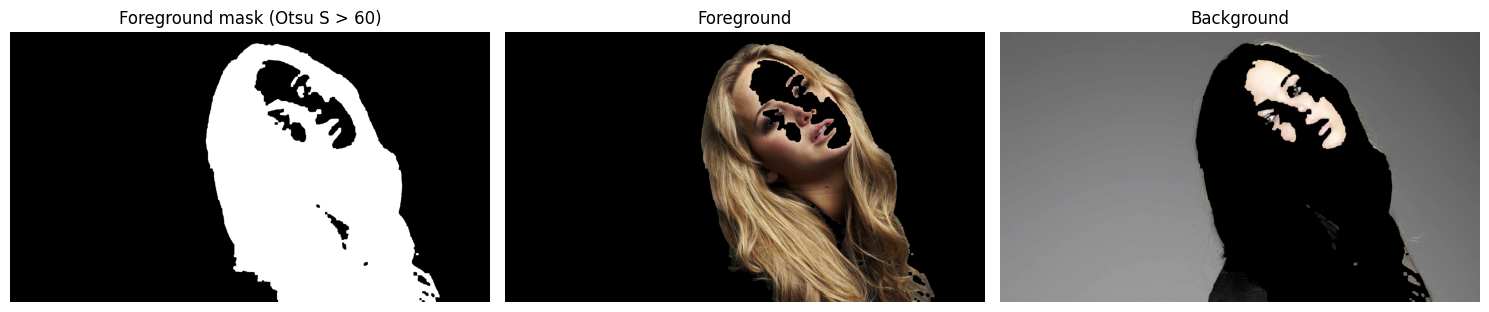

In [110]:
# --- Threshold the Saturation plane (Otsu picks the cutoff automatically) to get the mask ---
otsu_val, mask6 = cv2.threshold(s6, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Otsu threshold on S plane: {otsu_val}")   # = 60.0 on this image

kernel = np.ones((7, 7), np.uint8)
mask6 = cv2.morphologyEx(mask6, cv2.MORPH_CLOSE, kernel)   # fill small holes
mask6 = cv2.morphologyEx(mask6, cv2.MORPH_OPEN, kernel)    # remove small speckles

foreground6 = cv2.bitwise_and(img6, img6, mask=mask6)
background6 = cv2.bitwise_and(img6, img6, mask=cv2.bitwise_not(mask6))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(mask6, cmap='gray'); axes[0].set_title(f"Foreground mask (Otsu S > {otsu_val:.0f})"); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(foreground6, cv2.COLOR_BGR2RGB)); axes[1].set_title("Foreground"); axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(background6, cv2.COLOR_BGR2RGB)); axes[2].set_title("Background"); axes[2].axis('off')
plt.tight_layout(); plt.show()

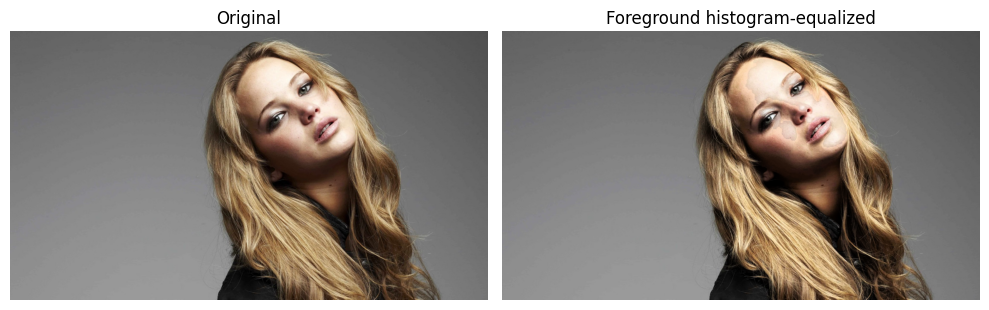

In [111]:
# --- Histogram-equalize the foreground, V channel only (keeps hue/saturation intact) ---
fg_v = v6[mask6 == 255]
hist6, _ = np.histogram(fg_v, bins=256, range=(0, 256))
cdf6 = hist6.cumsum()
cdf6_lut = np.round((cdf6 - cdf6.min()) * 255.0 / (cdf6.max() - cdf6.min())).astype(np.uint8)

v6_eq = v6.copy()
v6_eq[mask6 == 255] = cdf6_lut[v6[mask6 == 255]]

hsv6_eq = cv2.merge([h6, s6, v6_eq])
result6 = cv2.cvtColor(hsv6_eq, cv2.COLOR_HSV2BGR)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img6, cv2.COLOR_BGR2RGB)); axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(result6, cv2.COLOR_BGR2RGB)); axes[1].set_title("Foreground histogram-equalized"); axes[1].axis('off')
plt.tight_layout(); plt.show()

**Discussion-** The Otsu threshold on the S plane isolates the hair very cleanly (it's the most
saturated region in the frame) but excludes the face and jacket, since skin and dark fabric are nearly
as desaturated as the gray background - a genuine limitation of thresholding a single HSV plane rather
than doing proper foreground/background segmentation (c.f. the GrabCut approach used in Q9). Within the
masked hair region, equalization visibly boosts local contrast in the strands. For a cleaner full-body
mask, a next step would be to combine the S-plane threshold with a second cue (e.g. an edge map or a
GrabCut pass) rather than rely on saturation alone.


## Question 7 - Sobel filtering three ways


In [115]:
img7 = cv2.imread(IMG_DIR + "q7.jpeg", cv2.IMREAD_GRAYSCALE)

sobel_x = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float32)
sobel_y = sobel_x.T

**(a) Using `cv2.filter2D`**

In [116]:
gx_a = cv2.filter2D(img7.astype(np.float64), -1, sobel_x)
gy_a = cv2.filter2D(img7.astype(np.float64), -1, sobel_y)
grad_a = np.sqrt(gx_a ** 2 + gy_a ** 2)
grad_a = np.clip(grad_a / grad_a.max() * 255, 0, 255).astype(np.uint8)


**(b) Own convolution code (no `filter2D`)**

In [117]:
def convolve2d(img, kernel):
    """'Real' convolution (kernel flipped), reflect-padded border."""
    img = img.astype(np.float64)
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(img, ((ph, ph), (pw, pw)), mode='reflect')
    kernel_flipped = np.flipud(np.fliplr(kernel))
    out = np.zeros_like(img)
    for i in range(kh):
        for j in range(kw):
            out += kernel_flipped[i, j] * padded[i:i + img.shape[0], j:j + img.shape[1]]
    return out

gx_b = convolve2d(img7, sobel_x)
gy_b = convolve2d(img7, sobel_y)
grad_b = np.sqrt(gx_b ** 2 + gy_b ** 2)
grad_b = np.clip(grad_b / grad_b.max() * 255, 0, 255).astype(np.uint8)


**(c) Separable convolution: `[[1,0,-1],[2,0,-2],[1,0,-1]] = [1,2,1]ᵀ * [1,0,-1]`**

In [118]:
col = np.array([[1], [2], [1]], dtype=np.float32)
row = np.array([[1, 0, -1]], dtype=np.float32)

gx_c = convolve2d(convolve2d(img7, col), row)
gy_c = convolve2d(convolve2d(img7, row.T), col.T)
grad_c = np.sqrt(gx_c ** 2 + gy_c ** 2)
grad_c = np.clip(grad_c / grad_c.max() * 255, 0, 255).astype(np.uint8)

print("max abs diff between direct and separable Gx:", np.max(np.abs(gx_b - gx_c)))


max abs diff between direct and separable Gx: 0.0


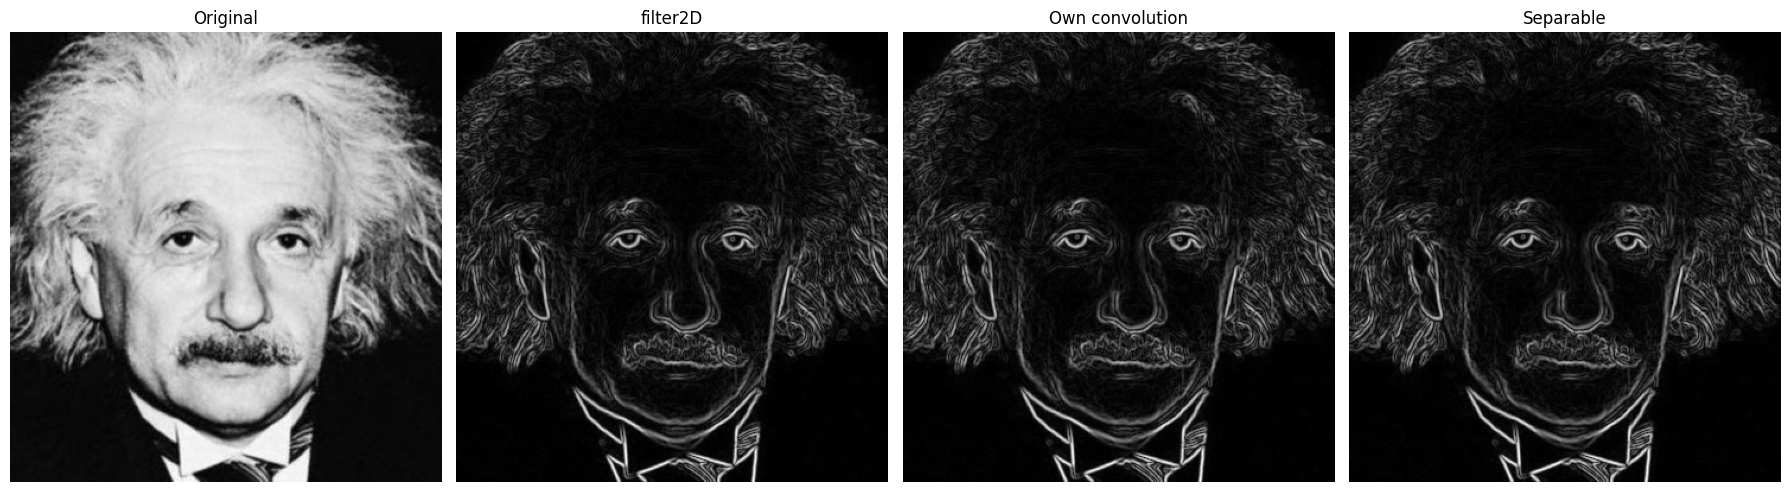

In [119]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(img7, cmap='gray'); axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(grad_a, cmap='gray'); axes[1].set_title("filter2D"); axes[1].axis('off')
axes[2].imshow(grad_b, cmap='gray'); axes[2].set_title("Own convolution"); axes[2].axis('off')
axes[3].imshow(grad_c, cmap='gray'); axes[3].set_title("Separable"); axes[3].axis('off')
plt.tight_layout(); plt.show()


**Discussion-** All three methods produce identical gradient maps (the printed max-abs-difference
between the direct and separable Gx is 0, confirming the factorisation is exact) - the hair, eyes and
moustache edges come through cleanly against the flat black background. The separable form does the
same computation in `O(2·d)` multiply-adds per pixel instead of `O(d²)`, i.e. 6 instead of 9 for this
3×3 kernel - a small saving here, but the gap grows quickly for larger derivative-of-Gaussian kernels.


## Question 8 - Zooming with nearest-neighbour and bilinear interpolation




Four large/small pairs were supplied, each the small image being an exact 1/4-scale (in both
dimensions) downsample of its matching large original:

| pair | large | small |
|---|---|---|
| 1 | `im01.png` — 1920x1080 | `im01small.png` — 480x270 |
| 2 | `im02.png` — 1920x1200 | `im02small.png` — 480x300 |
| 3 | `im03.png` — 2400x1459 | `im03small.png` — 600x365 |
| 4 | `im04.jpg` — 200x112 | `im04small.jpg` — 50x28 |

In [123]:
def zoom_image(img, s, method='nearest'):
    """
    img: HxW or HxWxC uint8 array
    s: zoom factor in (0, 10]
    method: 'nearest' or 'bilinear'
    """
    single_channel = (img.ndim == 2)
    if single_channel:
        img = img[:, :, None]
    h, w, c = img.shape
    new_h, new_w = max(1, int(round(h * s))), max(1, int(round(w * s)))

    ys = np.arange(new_h) / s
    xs = np.arange(new_w) / s

    if method == 'nearest':
        sy = np.clip(np.round(ys).astype(int), 0, h - 1)
        sx = np.clip(np.round(xs).astype(int), 0, w - 1)
        out = img[sy[:, None], sx[None, :], :]

    elif method == 'bilinear':
        y0 = np.clip(np.floor(ys).astype(int), 0, h - 1)
        y1 = np.clip(y0 + 1, 0, h - 1)
        x0 = np.clip(np.floor(xs).astype(int), 0, w - 1)
        x1 = np.clip(x0 + 1, 0, w - 1)
        dy = (ys - y0)[:, None, None]
        dx = (xs - x0)[None, :, None]

        Ia = img[y0[:, None], x0[None, :], :].astype(np.float64)
        Ib = img[y0[:, None], x1[None, :], :].astype(np.float64)
        Ic = img[y1[:, None], x0[None, :], :].astype(np.float64)
        Id = img[y1[:, None], x1[None, :], :].astype(np.float64)

        top = Ia * (1 - dx) + Ib * dx
        bottom = Ic * (1 - dx) + Id * dx
        out = np.clip(top * (1 - dy) + bottom * dy, 0, 255).astype(img.dtype)
    else:
        raise ValueError("method must be 'nearest' or 'bilinear'")

    return out[:, :, 0] if single_channel else out


def normalized_ssd(im1, im2):
    h = min(im1.shape[0], im2.shape[0])
    w = min(im1.shape[1], im2.shape[1])
    a = im1[:h, :w].astype(np.float64)
    b = im2[:h, :w].astype(np.float64)
    return np.sum((a - b) ** 2) / a.size

In [127]:
pairs = [
    ("im01.png", "im01small.png"),
    ("im02.png", "im02small.png"),
    ("im03.png", "im03small.png"),
    ("im04.jpg", "im04small.jpg"),
]

results = []
for large_name, small_name in pairs:
    large_orig = cv2.imread(IMG_DIR + large_name)
    small_img = cv2.imread(IMG_DIR + small_name)

    up_nn = zoom_image(small_img, 4, method='nearest')
    up_bl = zoom_image(small_img, 4, method='bilinear')

    ssd_nn = normalized_ssd(large_orig, up_nn)
    ssd_bl = normalized_ssd(large_orig, up_bl)
    results.append((large_name, ssd_nn, ssd_bl))

print(f"{'image':<16}{'SSD (nearest)':>16}{'SSD (bilinear)':>16}")
for name, ssd_nn, ssd_bl in results:
    print(f"{name:<16}{ssd_nn:>16.2f}{ssd_bl:>16.2f}")

image              SSD (nearest)  SSD (bilinear)
im01.png                  255.30          200.25
im02.png                   64.63           48.96
im03.png                  129.71           98.06
im04.jpg                  409.89          329.25


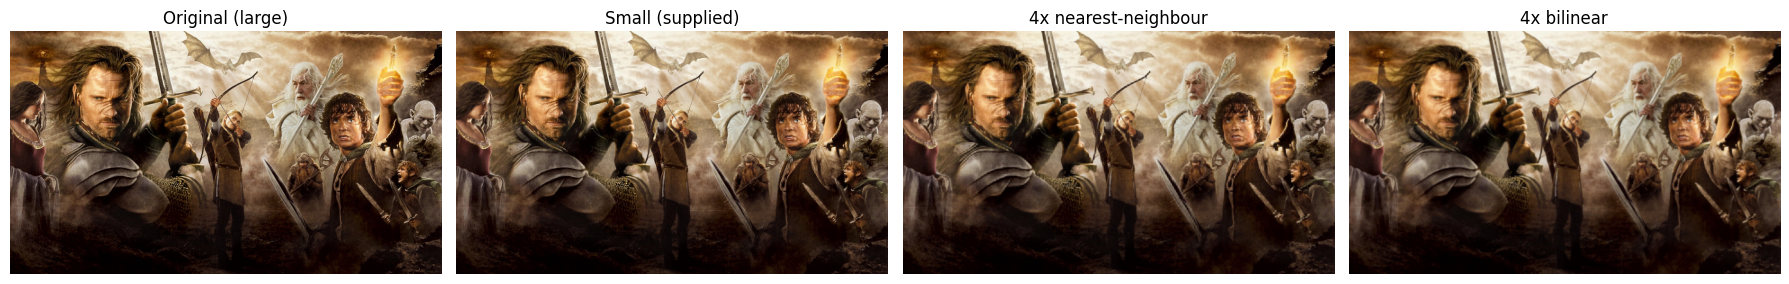

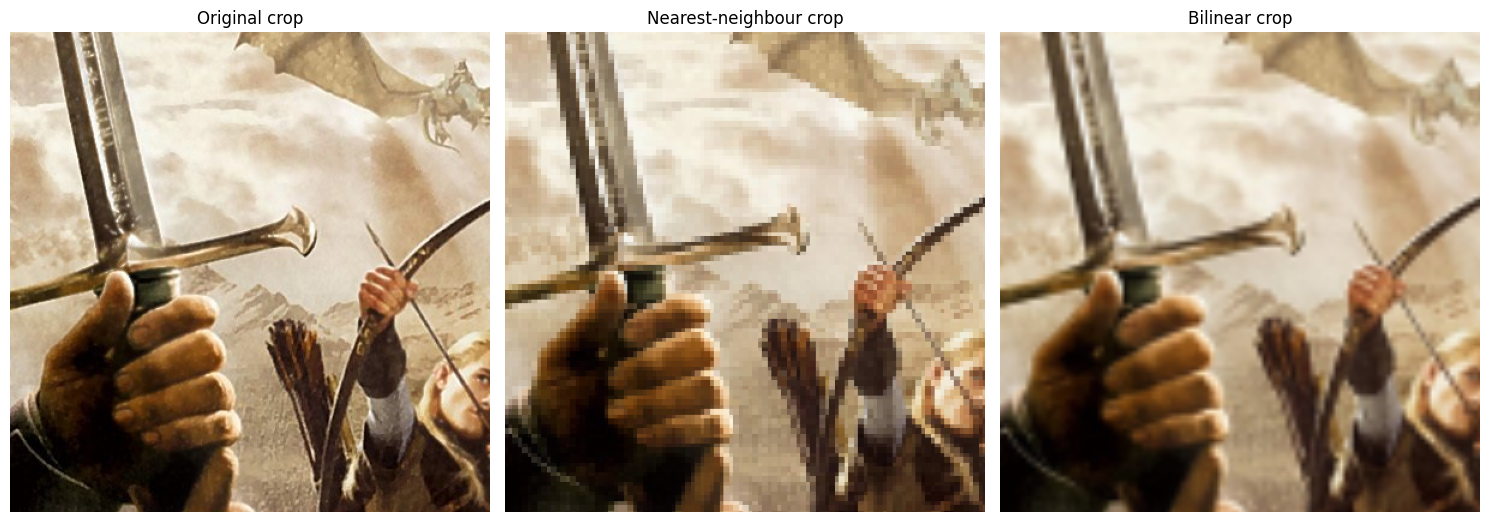

In [128]:
# Visual comparison for one representative pair (im01 -- the LOTR poster)
large_orig = cv2.imread(IMG_DIR + "im01.png")
small_img = cv2.imread(IMG_DIR + "im01small.png")
up_nn = zoom_image(small_img, 4, method='nearest')
up_bl = zoom_image(small_img, 4, method='bilinear')

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(cv2.cvtColor(large_orig, cv2.COLOR_BGR2RGB)); axes[0].set_title("Original (large)"); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(small_img, cv2.COLOR_BGR2RGB)); axes[1].set_title("Small (supplied)"); axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(up_nn, cv2.COLOR_BGR2RGB)); axes[2].set_title("4x nearest-neighbour"); axes[2].axis('off')
axes[3].imshow(cv2.cvtColor(up_bl, cv2.COLOR_BGR2RGB)); axes[3].set_title("4x bilinear"); axes[3].axis('off')
plt.tight_layout(); plt.show()

# Zoomed-in crop on a detail region to make the interpolation difference visible
crop = lambda im, y0,y1,x0,x1: im[y0:y1, x0:x1]
y0,y1,x0,x1 = 100, 500, 600, 1000
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes[0].imshow(cv2.cvtColor(crop(large_orig,y0,y1,x0,x1), cv2.COLOR_BGR2RGB)); axes[0].set_title("Original crop"); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(crop(up_nn,y0,y1,x0,x1), cv2.COLOR_BGR2RGB)); axes[1].set_title("Nearest-neighbour crop"); axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(crop(up_bl,y0,y1,x0,x1), cv2.COLOR_BGR2RGB)); axes[2].set_title("Bilinear crop"); axes[2].axis('off')
plt.tight_layout(); plt.show()

**Results (normalized SSD, 4x upscale vs. the true large original):**

| image | SSD nearest-neighbour | SSD bilinear |
|---|---|---|
| im01 (LOTR poster) | 255.30 | 200.25 |
| im02 (Arwen) | 64.63 | 48.96 |
| im03 (Ravenna) | 129.71 | 98.06 |
| im04 (Taylor Swift) | 409.89 | 329.25 |

**Discussion-** Bilinear interpolation gives a lower normalized SSD than nearest-neighbour on **every
single one** of the four pairs - a 20–25% reduction in error each time. This matches expectation:
nearest-neighbour just repeats the nearest known pixel, producing hard blocky steps at every edge
(visible clearly in the zoomed-in crop above - note the staircase artifacts along the sword and
Gandalf's staff), while bilinear interpolates a weighted average between the four nearest known pixels,
producing a smoother result that sits numerically closer to what a full-resolution capture would have
looked like. The relative gap is smallest for im02 (Arwen - a soft-focus portrait with few hard edges,
so nearest-neighbour's blockiness matters less) and largest for im04 (Taylor Swift - the smallest,
most heavily downsampled image, where every interpolation choice has more relative impact per pixel).